## DSC 680 Week Project 2
### What Influences Housing Prices?

Caitie Schrotberger \
Bellevue University \
DSC680-T301 Applied Data Science (2267-1) \
Sue Ashton \
August 16, 2026

In [1]:
# Import packages needed for analysis
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error

In [2]:
# Import CSV to dataframe
housing_data=pd.read_csv(r'G:/My Drive/College/Caitie/DSC680/Project2/redfin_single_family_residential_2016_2026.csv')
mortgage=pd.read_csv(r'G:/My Drive/College/Caitie/DSC680/Project2/MORTGAGE30USMONTHLY.csv')

# Display first 5 rows of data
housing_data.head()

,LAST UPDATED,FREQUENCY,PERIOD BEGIN,PERIOD END,REGION ID,REGION TYPE,REGION NAME,PROPERTY TYPE,IS SEASONALLY ADJUSTED,HOMES SOLD,...,MEDIAN NEW LISTING PRICE ($),MEDIAN NEW LISTING PRICE YOY (%),MEDIAN NEW LISTING PRICE PER SQ.FT. ($),MEDIAN NEW LISTING PRICE PER SQ.FT. YOY (%),MEDIAN SALE PRICE PER SQ.FT. ($),MEDIAN SALE PRICE PER SQ.FT. YOY (%),MONTHS OF SUPPLY,MONTHS OF SUPPLY YOY (%),PERCENT OFF MARKET IN TWO WEEKS (%),PERCENT OFF MARKET IN TWO WEEKS YOY (PPTS)
0,8/3/2026,Monthly,1/1/2016,1/31/2016,NaN,Country,National,Single Family Residential,True,269912,...,232434,6.72,117.61,6.17,111.80,5.55,4.4,-88.82,20.37,4.25
1,8/3/2026,Monthly,2/1/2016,2/29/2016,NaN,Country,National,Single Family Residential,True,256233,...,233151,5.11,118.04,5.51,111.52,4.51,4.6,-39.96,21.26,4.27
2,8/3/2026,Monthly,3/1/2016,3/31/2016,NaN,Country,National,Single Family Residential,True,255686,...,235964,7.07,118.55,5.40,111.91,4.34,4.6,-37.72,21.87,4.86
3,8/3/2026,Monthly,4/1/2016,4/30/2016,NaN,Country,National,Single Family Residential,True,269877,...,234593,5.65,118.87,5.25,112.63,4.79,4.4,-55.77,22.32,3.84
4,8/3/2026,Monthly,5/1/2016,5/31/2016,NaN,Country,National,Single Family Residential,True,273174,...,235890,5.44,119.08,4.98,113.03,4.40,4.2,-62.74,22.37,3.40


In [3]:
mortgage.head()

,observation_date,MORTGAGE30US
0,1/31/2016,3.79
1,2/29/2016,3.62
2,3/31/2016,3.71
3,4/30/2016,3.66
4,5/31/2016,3.64


In [4]:
housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 37 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   LAST UPDATED                                 127 non-null    str    
 1   FREQUENCY                                    127 non-null    str    
 2   PERIOD BEGIN                                 127 non-null    str    
 3   PERIOD END                                   127 non-null    str    
 4   REGION ID                                    0 non-null      float64
 5   REGION TYPE                                  127 non-null    str    
 6   REGION NAME                                  127 non-null    str    
 7   PROPERTY TYPE                                127 non-null    str    
 8   IS SEASONALLY ADJUSTED                       127 non-null    bool   
 9   HOMES SOLD                                   127 non-null    int64  
 10  HOMES SOLD YO

In [5]:
housing_data = housing_data.drop(columns=['LAST UPDATED', 'FREQUENCY', 'PERIOD BEGIN', 'REGION ID','REGION TYPE','REGION NAME',
                                          'PROPERTY TYPE','IS SEASONALLY ADJUSTED'])

In [6]:
housing_data['PERIOD END'] = pd.to_datetime(housing_data['PERIOD END'])
mortgage['observation_date'] = pd.to_datetime(mortgage['observation_date'])

housing_data = pd.merge(housing_data, mortgage, left_on='PERIOD END', right_on='observation_date', how='inner')
housing_data = housing_data.drop(housing_data.columns[[29]], axis=1)
housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 30 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   PERIOD END                                   127 non-null    datetime64[us]
 1   HOMES SOLD                                   127 non-null    int64         
 2   HOMES SOLD YOY (%)                           127 non-null    float64       
 3   MEDIAN SALE PRICE NSA ($)                    127 non-null    int64         
 4   MEDIAN SALE PRICE NSA YOY (%)                127 non-null    float64       
 5   MEDIAN DAYS ON MARKET (DAYS)                 127 non-null    int64         
 6   MEDIAN DAYS ON MARKET YOY (%)                127 non-null    int64         
 7   AVERAGE SALE TO LIST RATIO (%)               127 non-null    float64       
 8   AVERAGE SALE TO LIST RATIO YOY (PPTS)        127 non-null    float64       
 9   SHARE SOLD

In [7]:
housing_data.head()

,PERIOD END,HOMES SOLD,HOMES SOLD YOY (%),MEDIAN SALE PRICE NSA ($),MEDIAN SALE PRICE NSA YOY (%),MEDIAN DAYS ON MARKET (DAYS),MEDIAN DAYS ON MARKET YOY (%),AVERAGE SALE TO LIST RATIO (%),AVERAGE SALE TO LIST RATIO YOY (PPTS),SHARE SOLD ABOVE ORIGINAL LIST (%),...,MEDIAN NEW LISTING PRICE YOY (%),MEDIAN NEW LISTING PRICE PER SQ.FT. ($),MEDIAN NEW LISTING PRICE PER SQ.FT. YOY (%),MEDIAN SALE PRICE PER SQ.FT. ($),MEDIAN SALE PRICE PER SQ.FT. YOY (%),MONTHS OF SUPPLY,MONTHS OF SUPPLY YOY (%),PERCENT OFF MARKET IN TWO WEEKS (%),PERCENT OFF MARKET IN TWO WEEKS YOY (PPTS),MORTGAGE30US
0,2016-01-31,269912,14.75,205900,8.37,69,-900,97.50,0.43,18.12,...,6.72,117.61,6.17,111.80,5.55,4.4,-88.82,20.37,4.25,3.79
1,2016-02-29,256233,6.62,203000,4.64,69,-800,97.46,0.33,18.25,...,5.11,118.04,5.51,111.52,4.51,4.6,-39.96,21.26,4.27,3.62
2,2016-03-31,255686,3.01,212100,5.00,68,-800,97.45,0.26,18.70,...,7.07,118.55,5.40,111.91,4.34,4.6,-37.72,21.87,4.86,3.71
3,2016-04-30,269877,8.94,219000,4.78,66,-800,97.48,0.27,19.09,...,5.65,118.87,5.25,112.63,4.79,4.4,-55.77,22.32,3.84,3.66
4,2016-05-31,273174,7.12,225000,3.69,66,-600,97.50,0.27,19.33,...,5.44,119.08,4.98,113.03,4.40,4.2,-62.74,22.37,3.40,3.64


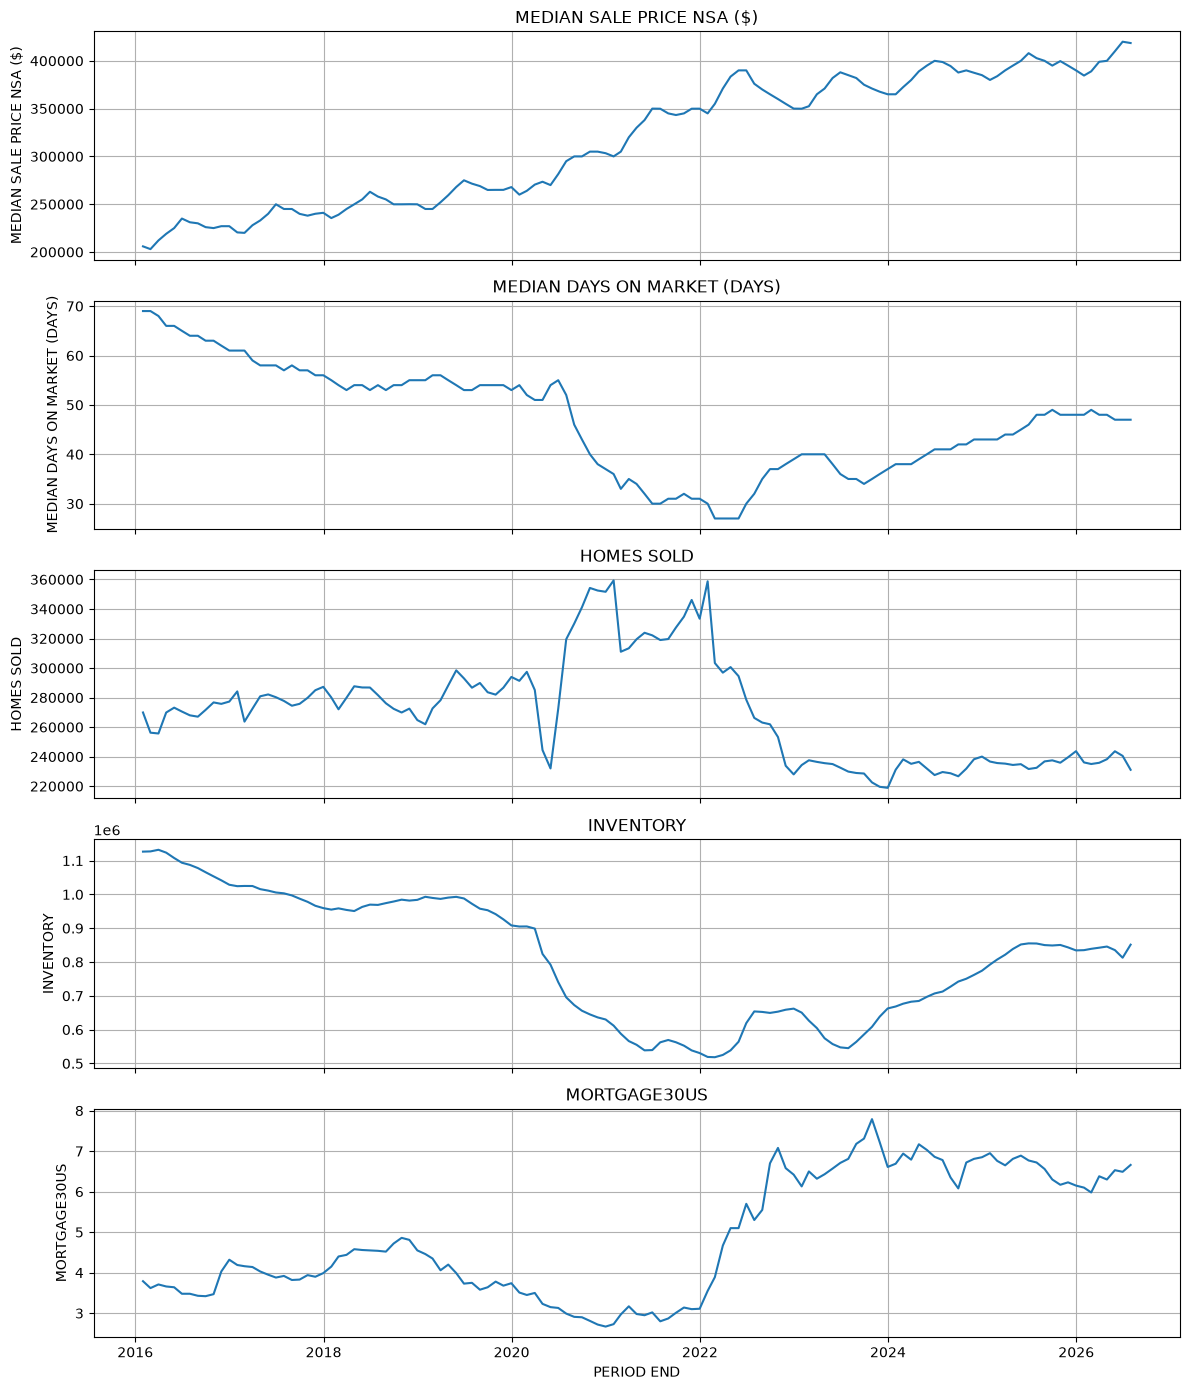

In [8]:
# Small Multiples Time Series Review
metrics = [
    "MEDIAN SALE PRICE NSA ($)",
    "MEDIAN DAYS ON MARKET (DAYS)",
    "HOMES SOLD",
    "INVENTORY",
    "MORTGAGE30US"
]

fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 14), sharex=True)

for ax, col in zip(axes, metrics):
    sns.lineplot(data=housing_data, x="PERIOD END", y=col, ax=ax)
    ax.set_title(col)
    ax.grid(True)

plt.tight_layout()
plt.show()

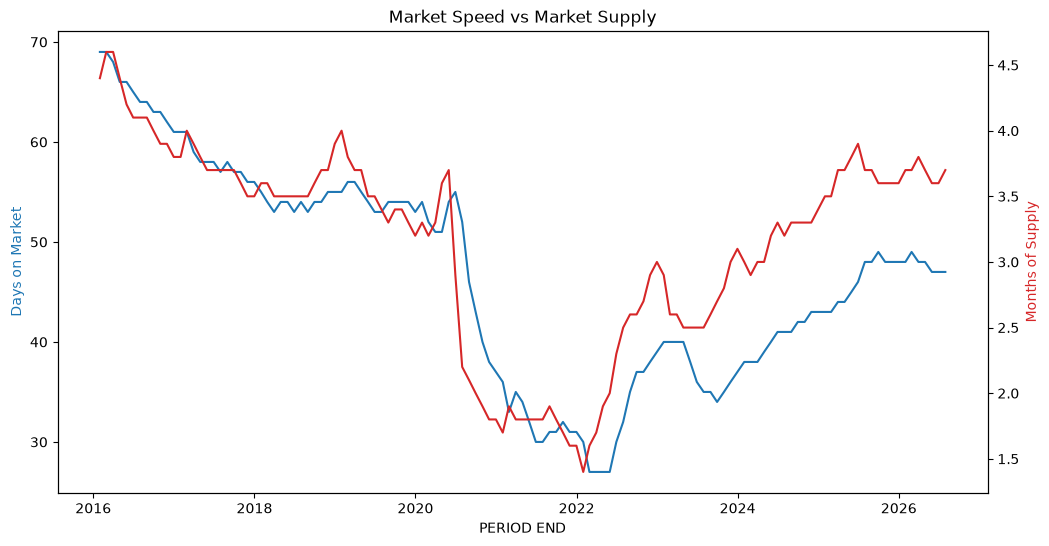

In [9]:
#Market Balance - Days on Market vs Months of Supply
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(data=housing_data, x="PERIOD END", y="MEDIAN DAYS ON MARKET (DAYS)", ax=ax1, color="tab:blue")
ax1.set_ylabel("Days on Market", color="tab:blue")

ax2 = ax1.twinx()
sns.lineplot(data=housing_data, x="PERIOD END", y="MONTHS OF SUPPLY", ax=ax2, color="tab:red")
ax2.set_ylabel("Months of Supply", color="tab:red")

plt.title("Market Speed vs Market Supply")
plt.show()

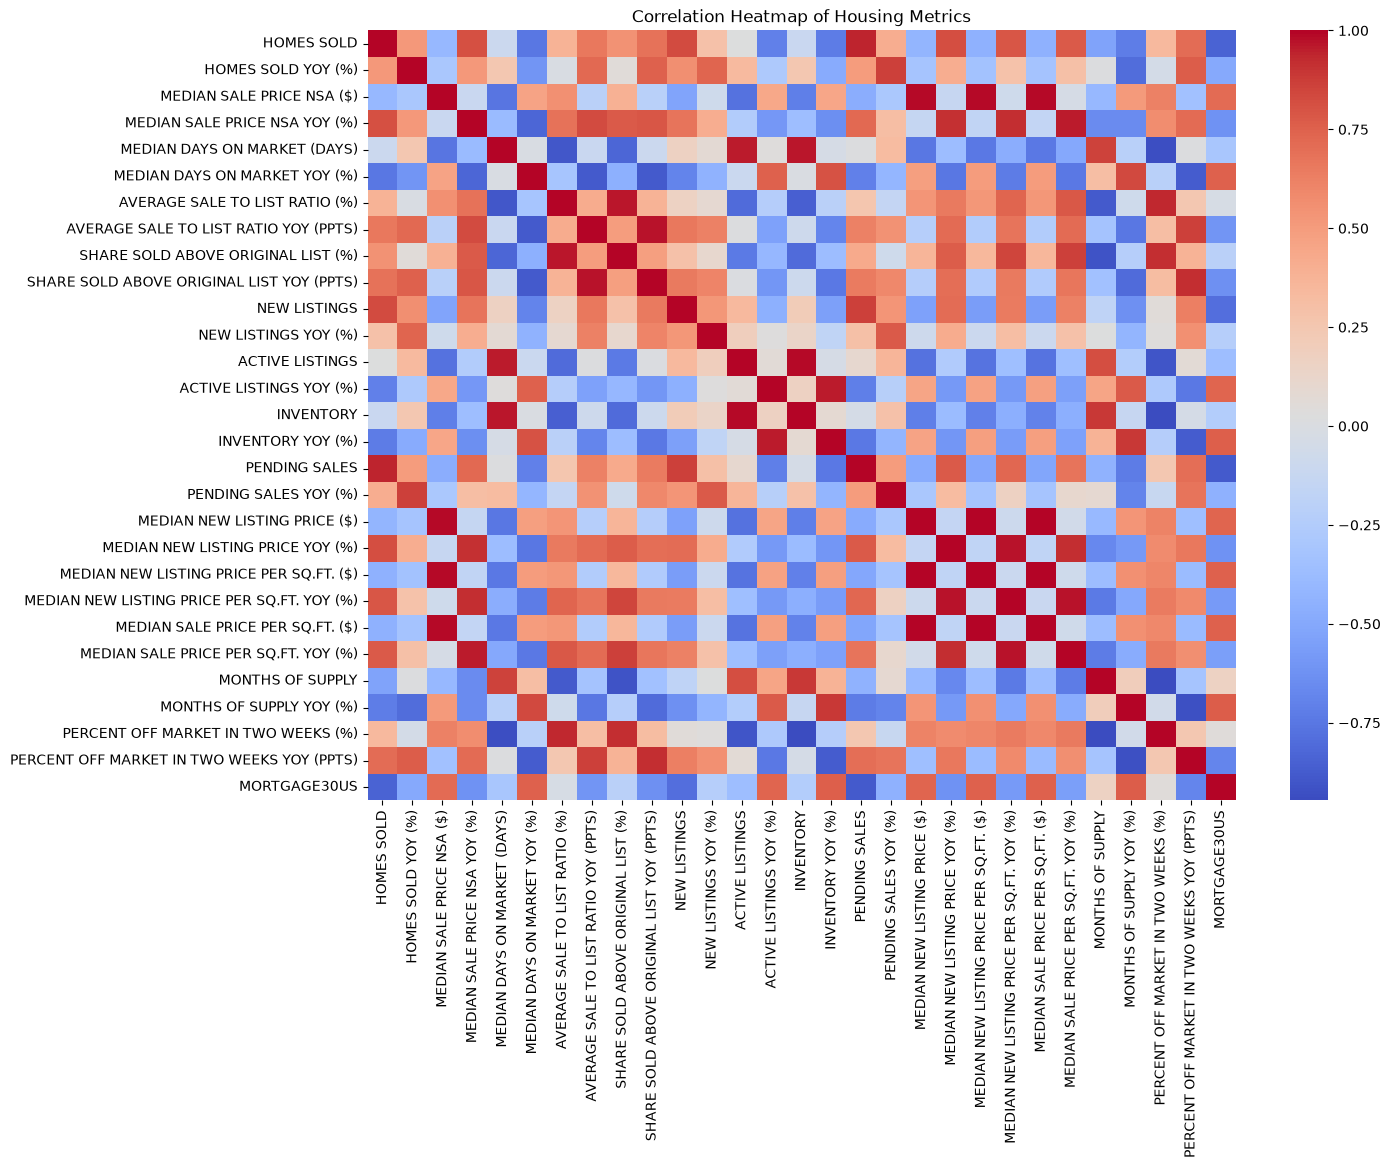

In [10]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
corr = housing_data.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Housing Metrics")
plt.show()

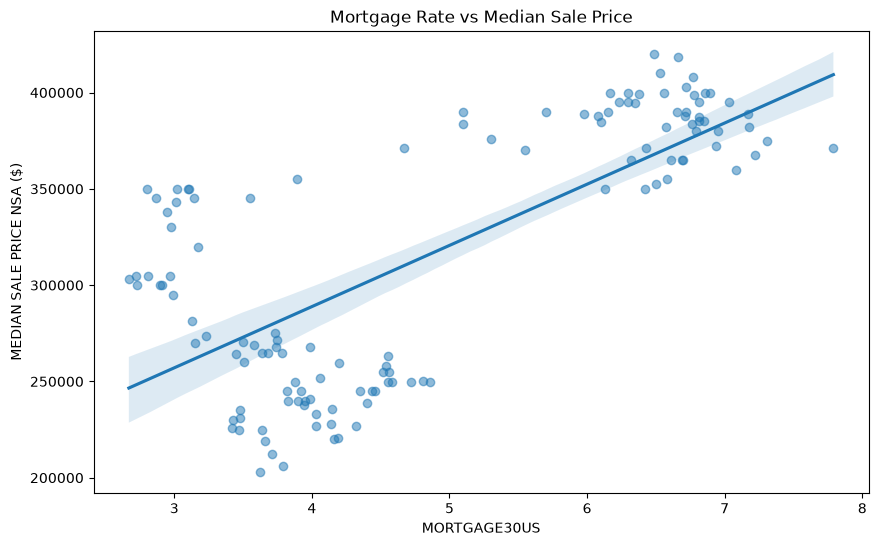

In [11]:
# Morgage Rate vs Median Sale Price Scatter Plot
plt.figure(figsize=(10,6))
sns.regplot(
    data=housing_data,
    x="MORTGAGE30US",
    y="MEDIAN SALE PRICE NSA ($)",
    scatter_kws={"alpha":0.5}
)
plt.title("Mortgage Rate vs Median Sale Price")
plt.show()

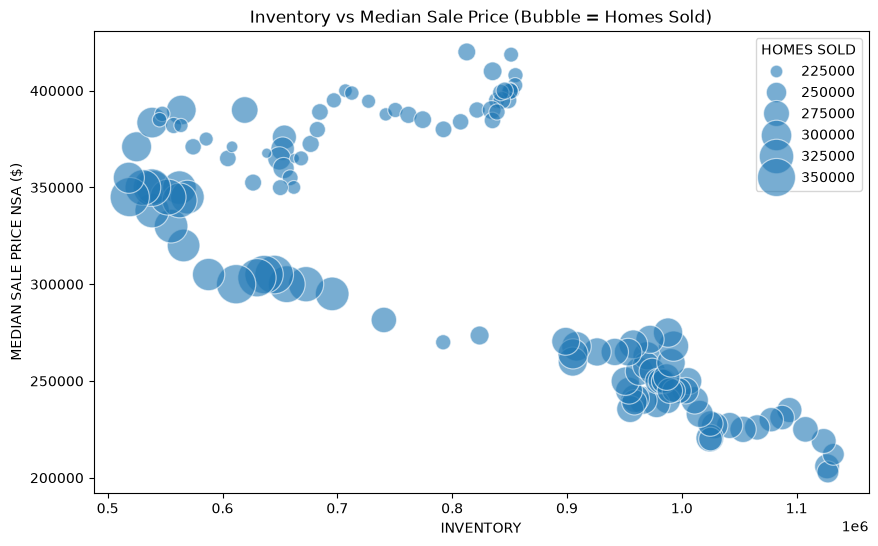

In [12]:
# Inventory vs. Median Sale Price Bubble Chart
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=housing_data,
    x="INVENTORY",
    y="MEDIAN SALE PRICE NSA ($)",
    size="HOMES SOLD",
    sizes=(50, 800),
    alpha=0.6
)
plt.title("Inventory vs Median Sale Price (Bubble = Homes Sold)")
plt.show()

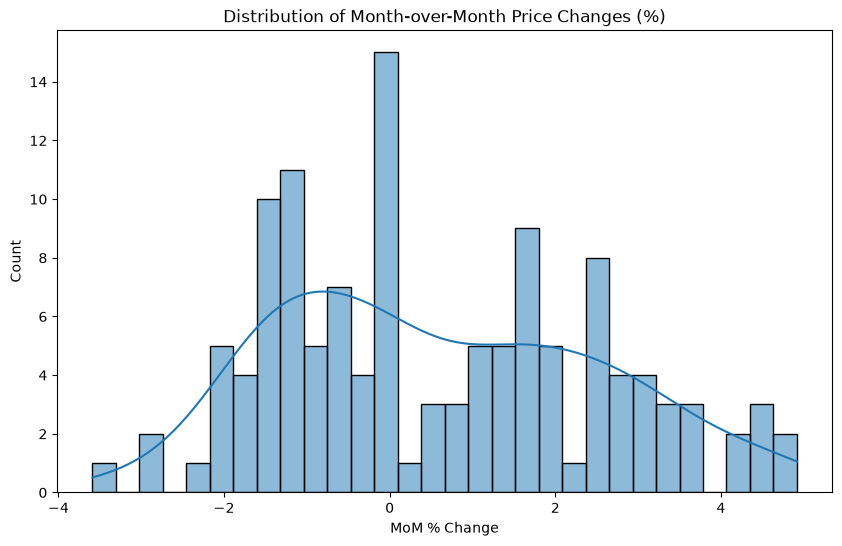

In [13]:
# Historgram Monthly Price Changes
housing_data["PRICE_MOM_PCT"] = housing_data["MEDIAN SALE PRICE NSA ($)"].pct_change() * 100

plt.figure(figsize=(10,6))
sns.histplot(housing_data["PRICE_MOM_PCT"].dropna(), kde=True, bins=30)
plt.title("Distribution of Month-over-Month Price Changes (%)")
plt.xlabel("MoM % Change")
plt.show()

### Logistic Regression

In [14]:
# Create target variable
target = "MEDIAN SALE PRICE NSA ($)"

In [15]:
# Create data frame without fields model can't evalute
keep_cols = [
    'HOMES SOLD',
    'MEDIAN DAYS ON MARKET (DAYS)',
    'AVERAGE SALE TO LIST RATIO (%)',
    'SHARE SOLD ABOVE ORIGINAL LIST (%)',
    'NEW LISTINGS',
    'ACTIVE LISTINGS',
    'INVENTORY',
    'PENDING SALES',
    'MEDIAN NEW LISTING PRICE ($)',
    'MEDIAN NEW LISTING PRICE PER SQ.FT. ($)',
    'MEDIAN SALE PRICE PER SQ.FT. ($)',
    'MONTHS OF SUPPLY',
    'PERCENT OFF MARKET IN TWO WEEKS (%)',
    'MORTGAGE30US']

X = housing_data[keep_cols].copy()
y = housing_data[target].copy()

In [16]:
#Split train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Define scaler and scale continous variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

lin_pred = lin_model.predict(X_test_scaled)

lin_r2 = r2_score(y_test, lin_pred)
lin_rmse = mean_squared_error(y_test, lin_pred)

print("Linear Regression R²:", lin_r2)
print("Linear Regression RMSE:", lin_rmse)

Linear Regression R²: 0.984598089635387
Linear Regression RMSE: 73208126.1495761


In [19]:
mae = mean_absolute_error(y_test, lin_pred)
mape = (mae / y_test.mean()) * 100

print("MAE:", mae)
print("MAPE:", mape)

MAE: 6882.598531361387
MAPE: 2.1712955526649913


In [20]:
coef = lin_model.coef_
importance = pd.Series(coef, index=keep_cols).sort_values(key=abs, ascending=False)

print("Linear Regression Feature Importance (by absolute coefficient):")
print(importance)

Linear Regression Feature Importance (by absolute coefficient):
MEDIAN SALE PRICE PER SQ.FT. ($)           131927.332580
MEDIAN NEW LISTING PRICE PER SQ.FT. ($)    -87186.332197
MEDIAN NEW LISTING PRICE ($)                20388.534721
ACTIVE LISTINGS                             15370.680201
INVENTORY                                  -13298.667846
HOMES SOLD                                  -7615.948178
PENDING SALES                                7615.574265
MEDIAN DAYS ON MARKET (DAYS)                -6032.469786
PERCENT OFF MARKET IN TWO WEEKS (%)          3211.510926
MORTGAGE30US                                -2645.257413
AVERAGE SALE TO LIST RATIO (%)              -2398.329337
NEW LISTINGS                                -1555.633931
SHARE SOLD ABOVE ORIGINAL LIST (%)          -1484.962764
MONTHS OF SUPPLY                             1302.083816
dtype: float64


In [21]:
# Random Forect Model
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=2
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred)

print("Random Forest R²:", rf_r2)
print("Random Forest RMSE:", rf_rmse)

Random Forest R²: 0.987346287406518
Random Forest RMSE: 60145434.29187058


In [22]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=keep_cols
).sort_values(ascending=False)

print("\nRandom Forest Feature Importance:")
print(importances)


Random Forest Feature Importance:
MEDIAN SALE PRICE PER SQ.FT. ($)           0.344872
MEDIAN NEW LISTING PRICE PER SQ.FT. ($)    0.328263
MEDIAN NEW LISTING PRICE ($)               0.297180
INVENTORY                                  0.005157
ACTIVE LISTINGS                            0.004578
AVERAGE SALE TO LIST RATIO (%)             0.004513
MORTGAGE30US                               0.002934
MEDIAN DAYS ON MARKET (DAYS)               0.002240
MONTHS OF SUPPLY                           0.002234
PERCENT OFF MARKET IN TWO WEEKS (%)        0.002075
HOMES SOLD                                 0.001925
NEW LISTINGS                               0.001457
SHARE SOLD ABOVE ORIGINAL LIST (%)         0.001325
PENDING SALES                              0.001246
dtype: float64


### Exploratory Data Analaysis:  Second File

In [23]:
# Import CSV to dataframe
housing_features=pd.read_csv(r'G:/My Drive/College/Caitie/DSC680/Project2/housing.csv')

# Display first 5 rows of data
housing_features.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [24]:
yes_no_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]
housing_features[yes_no_cols] = housing_features[yes_no_cols].replace({'yes': 1, 'no': 0})

In [25]:
housing_features = housing_features.drop(housing_features.columns[[12]], axis=1)

In [26]:
housing_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            545 non-null    int64 
 1   area             545 non-null    int64 
 2   bedrooms         545 non-null    int64 
 3   bathrooms        545 non-null    int64 
 4   stories          545 non-null    int64 
 5   mainroad         545 non-null    object
 6   guestroom        545 non-null    object
 7   basement         545 non-null    object
 8   hotwaterheating  545 non-null    object
 9   airconditioning  545 non-null    object
 10  parking          545 non-null    int64 
 11  prefarea         545 non-null    object
dtypes: int64(6), object(6)
memory usage: 51.2+ KB


In [27]:
housing_features.isna().sum()

price              0
area               0
bedrooms           0
bathrooms          0
stories            0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
parking            0
prefarea           0
dtype: int64

In [28]:
housing_features.describe(include='all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.0,545.0,545.0,545.0,545.0,545.000000,545.0
unique,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,NaN,2.0
top,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,NaN,0.0
freq,NaN,NaN,NaN,NaN,NaN,468.0,448.0,354.0,520.0,373.0,NaN,417.0
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN


<Axes: xlabel='price', ylabel='Count'>

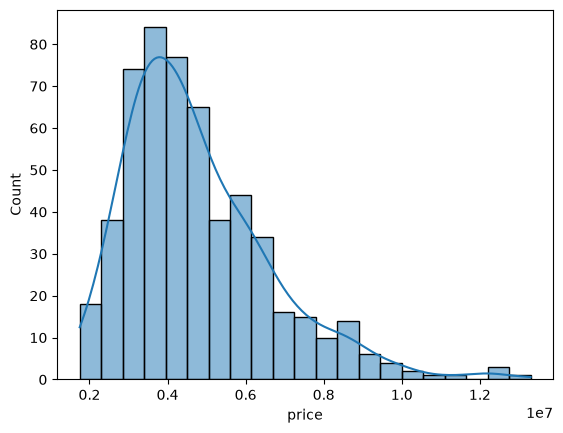

In [29]:
sns.histplot(housing_features['price'], kde=True)

<Axes: xlabel='bedrooms', ylabel='count'>

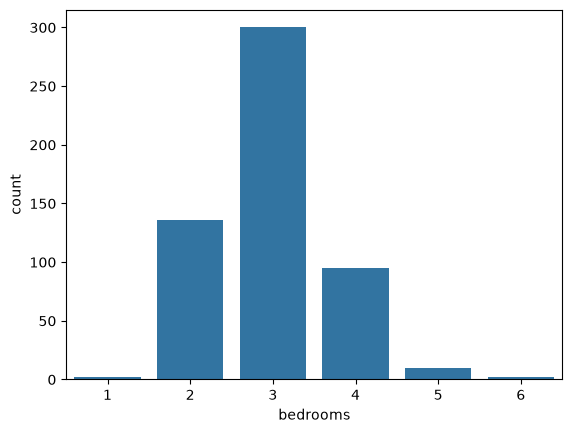

In [30]:
sns.countplot(x='bedrooms', data=housing_features)

<Axes: xlabel='bathrooms', ylabel='count'>

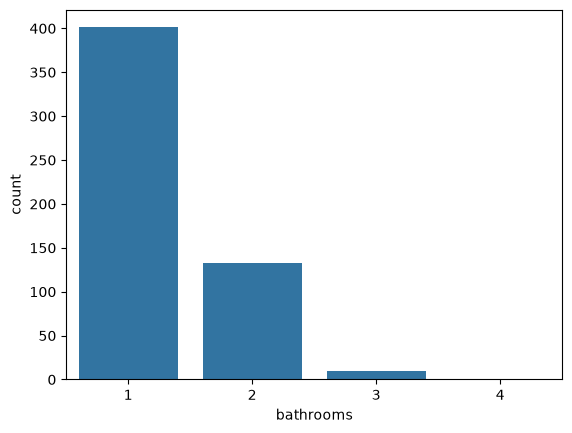

In [31]:
sns.countplot(x='bathrooms', data=housing_features)

<Axes: xlabel='parking', ylabel='count'>

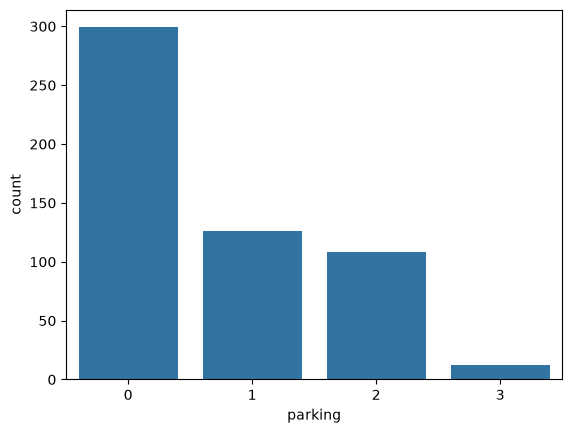

In [32]:
sns.countplot(x='parking', data=housing_features)

<Axes: xlabel='bedrooms', ylabel='price'>

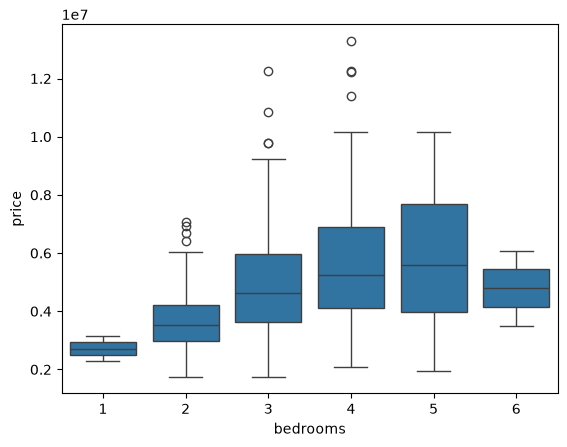

In [33]:
sns.boxplot(x='bedrooms', y='price', data=housing_features)

<Axes: xlabel='area', ylabel='price'>

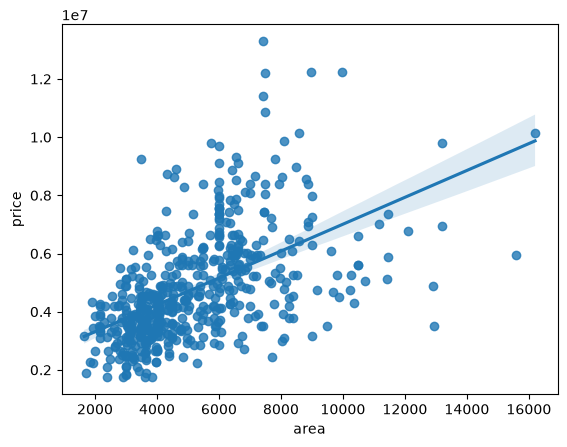

In [34]:
sns.regplot(x='area', y='price', data=housing_features)

<Axes: >

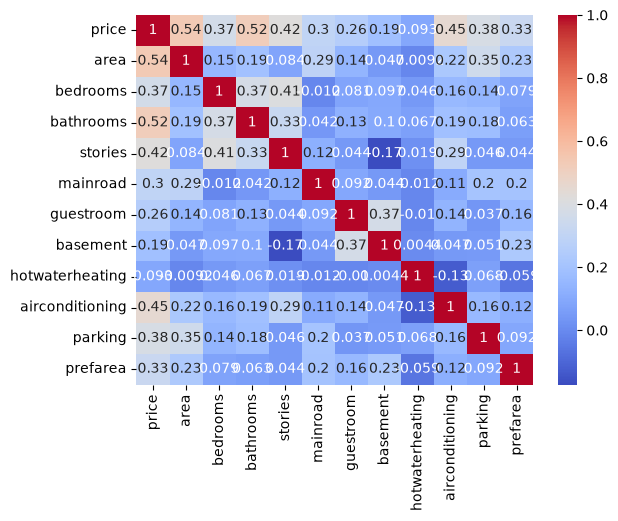

In [35]:
sns.heatmap(housing_features.corr(), annot=True, cmap='coolwarm')

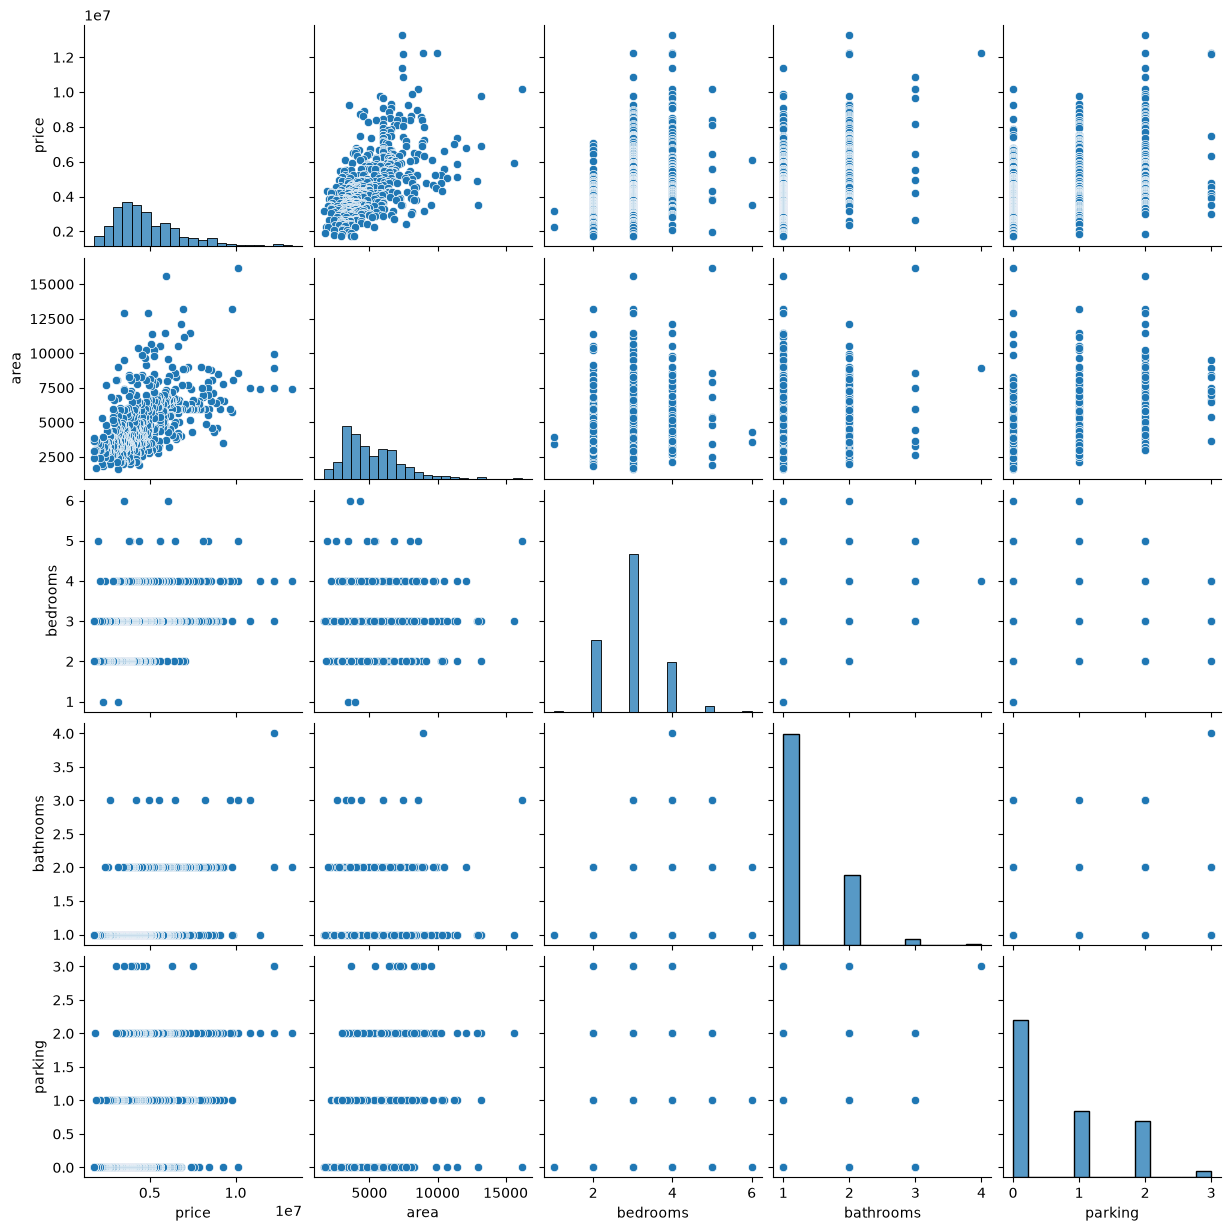

In [36]:
sns.pairplot(housing_features[['price','area','bedrooms','bathrooms','parking']])

### Logistice Regression Second File

In [37]:
# Create target variable
target2 = "price"

In [38]:
# Create data frame without fields model can't evalute
keep_cols2 = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea']
X2 = housing_features[keep_cols2].copy()
y2 = housing_features[target2].copy()

In [39]:
#Split train and test set
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [40]:
# Define scaler and scale continous variables
scaler = StandardScaler()
X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

In [41]:
# Linear Regression Model
lin_model2 = LinearRegression()
lin_model2.fit(X_train_scaled2, y_train2)
lin_pred2 = lin_model2.predict(X_test_scaled2)
lin_r2_2 = r2_score(y_test2, lin_pred2)
lin_rmse_2 = mean_squared_error(y_test2, lin_pred2)
print("Linear Regression R²:", lin_r2_2)
print("Linear Regression RMSE:", lin_rmse_2)

Linear Regression R²: 0.6437296086614108
Linear Regression RMSE: 1800793719718.9714


In [42]:
mae2 = mean_absolute_error(y_test2, lin_pred2)
mape2 = (mae2 / y_test2.mean()) * 100
print("MAE:", mae2)
print("MAPE:", mape2)

MAE: 979112.2162187381
MAPE: 19.552771660303314


In [43]:
coef2 = lin_model2.coef_
importance2 = pd.Series(coef2, index=keep_cols2).sort_values(key=abs, ascending=False)

print("Linear Regression Feature Importance (by absolute coefficient):")
print(importance2)

Linear Regression Feature Importance (by absolute coefficient):
bathrooms          528975.107549
area               523387.275608
airconditioning    372995.828406
stories            365907.580704
prefarea           269576.165624
parking            211306.488418
basement           208520.890548
hotwaterheating    155907.286870
mainroad           144130.607724
guestroom           93366.504672
bedrooms            58623.062293
dtype: float64
